<a href="https://colab.research.google.com/github/Venk-88/Machine-Learning-Project/blob/main/Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Classification of Breast Cancer Classification Using Patient’s Clinical Data**

# **Data files loading**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Defining base features and measurement types as per wdbc.names
base_features = ['radius', 'texture', 'perimeter', 'area', 'smoothness',
                 'compactness', 'concavity', 'concave_points', 'symmetry', 'fractal_dimension']
measurement_types = ['mean', 'se', 'worst']

# Constructing the full column list
columns = ['ID', 'Diagnosis']
for m_type in measurement_types:
    for feature in base_features:
        columns.append(f"{feature}_{m_type}")

# Loading the dataset
df = pd.read_csv('wdbc.data', header=None, names=columns)
df.head()

,ID,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


#**EDA**

## **Initial data inspection**

In [3]:
# General information about the dataset
print("Dataset Info:")
print(df.info())

# Summary statistics for numerical columns
print("\nStatistical Summary:")
display(df.describe())

# Checking for missing values
print("\nMissing Values:")
print(df.isnull().sum().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       569 non-null    int64  
 1   Diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se

,ID,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500



Missing Values:
0


## **Target variable distribution**

Percentage distribution:
Diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


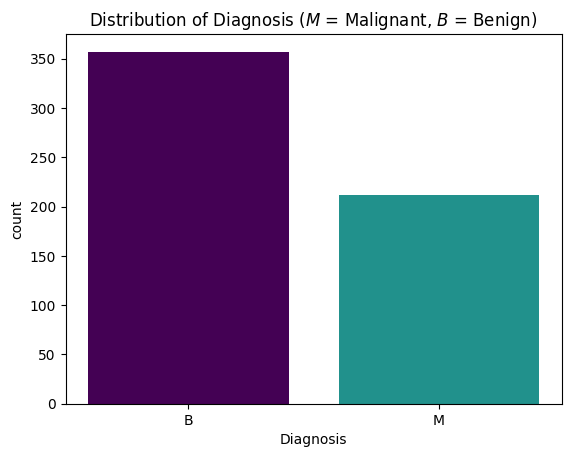

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Percentage distribution
percentages = df['Diagnosis'].value_counts(normalize=True) * 100
print("Percentage distribution:")
print(percentages)

# 2. Visualizing the count of Malignant vs Benign cases
# Get counts of each category
counts = df['Diagnosis'].value_counts()

# Use matplotlib's bar function
# Using hex codes for 'viridis' colors: dark purple for first, teal for second
plt.bar(counts.index, counts.values, color=['#440154', '#21918c'])

# Adding labels and title with LaTeX for scientific notation
plt.xlabel('Diagnosis')
plt.ylabel('count')
plt.title('Distribution of Diagnosis ($M$ = Malignant, $B$ = Benign)')

# Save the plot as an image file
plt.savefig('diagnosis_distribution.png')

## **Numerical feature distribution**

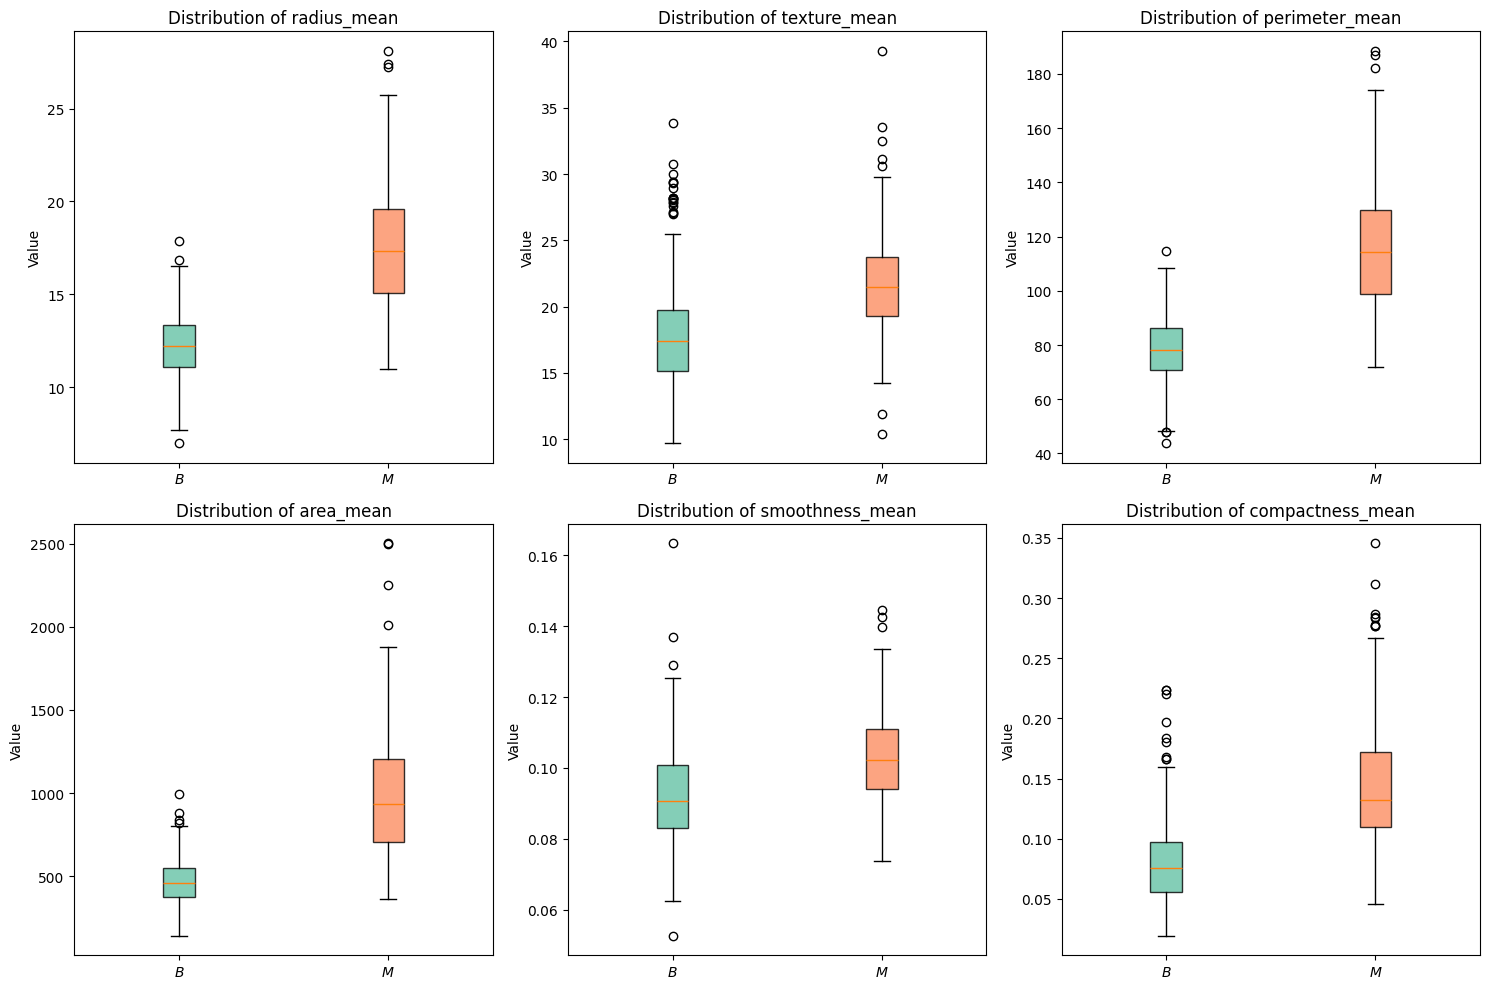

In [5]:
import matplotlib.pyplot as plt

# Identifying mean columns
mean_cols = [col for col in df.columns if '_mean' in col]
colors = ['#66c2a5', '#fc8d62']

plt.figure(figsize=(15, 10))

for i, col in enumerate(mean_cols[0:6]):
    plt.subplot(2, 3, i + 1)

    # Prepare data for boxplot
    group_data = [df[df['Diagnosis'] == 'B'][col],
                  df[df['Diagnosis'] == 'M'][col]]

    # FIX: Changed 'labels' to 'tick_labels' to remove deprecation warning
    bp = plt.boxplot(group_data, tick_labels=['$B$', '$M$'], patch_artist=True)

    # Apply colors
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    plt.title(f'Distribution of {col}')
    plt.ylabel('Value')

plt.tight_layout()
plt.show()

## **Correlation analysis**

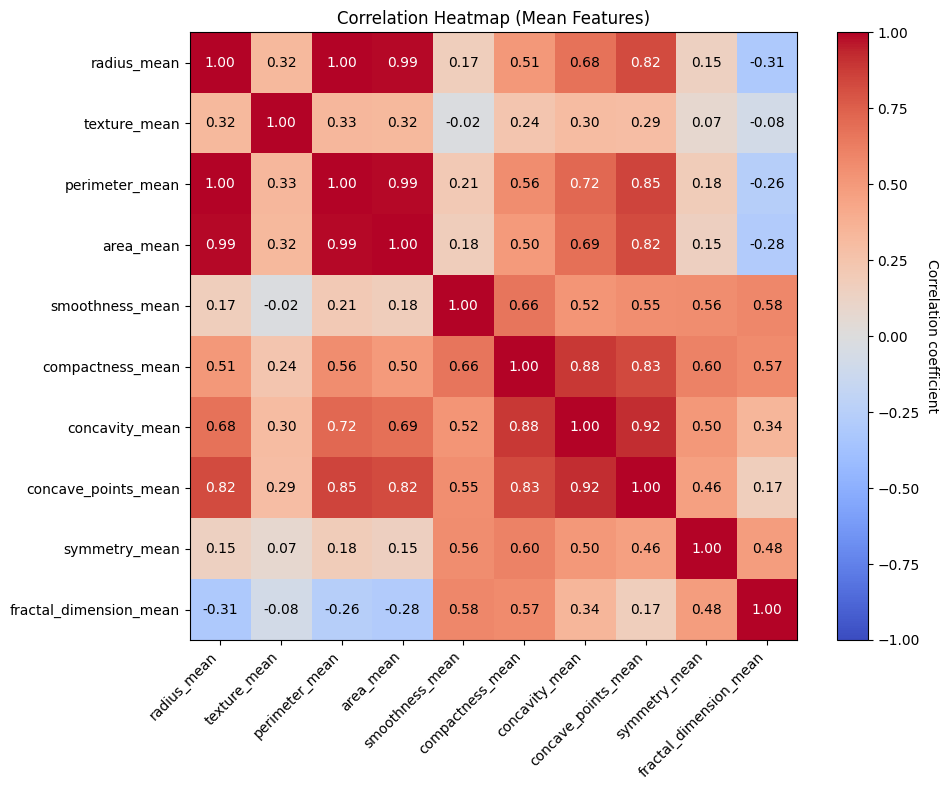

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Compute correlation matrix
corr_matrix = df[mean_cols].corr()

# 2. Create the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Use imshow to create the heatmap (using 'coolwarm' colormap)
im = ax.imshow(corr_matrix, cmap='coolwarm', interpolation='nearest', vmin=-1, vmax=1)

# Add colorbar to the right
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Correlation coefficient", rotation=-90, va="bottom")

# Setting the ticks and labels
ax.set_xticks(np.arange(len(mean_cols)))
ax.set_yticks(np.arange(len(mean_cols)))
ax.set_xticklabels(mean_cols, rotation=45, ha="right")
ax.set_yticklabels(mean_cols)

# Loop to add text annotations (mimicking annot=True, fmt=".2f")
for i in range(len(mean_cols)):
    for j in range(len(mean_cols)):
        text = ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                       ha="center", va="center", color="black" if abs(corr_matrix.iloc[i, j]) < 0.7 else "white")

ax.set_title('Correlation Heatmap (Mean Features)')
plt.tight_layout()
plt.show()

## **Multivariate scatter analysis**

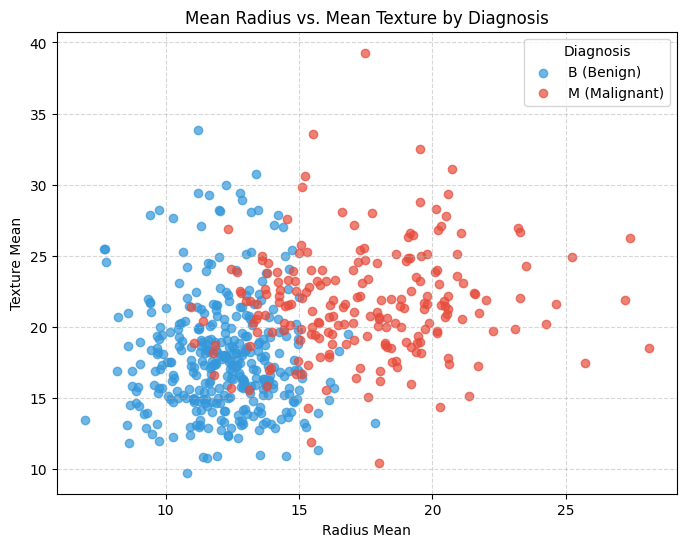

In [7]:
plt.figure(figsize=(8, 6))

# Filter data by diagnosis
df_b = df[df['Diagnosis'] == 'B']
df_m = df[df['Diagnosis'] == 'M']

# Plot each group
plt.scatter(df_b['radius_mean'], df_b['texture_mean'], color='#3498db', alpha=0.7, label='B (Benign)')
plt.scatter(df_m['radius_mean'], df_m['texture_mean'], color='#e74c3c', alpha=0.7, label='M (Malignant)')

# Formatting
plt.title('Mean Radius vs. Mean Texture by Diagnosis')
plt.xlabel('Radius Mean')
plt.ylabel('Texture Mean')
plt.legend(title='Diagnosis')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [8]:
df.head()

,ID,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# **Preprocessing**

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# 1. Separate Features and Target
X = df.drop(['ID', 'Diagnosis'], axis=1)
y = df['Diagnosis']

# 2. Encode Labels (M -> 1, B -> 0)
le = LabelEncoder()
y = le.fit_transform(y)

# 3. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Feature Scaling (Crucial for Logistic Regression and SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **Model Training and Evaluation**

MODEL: Logistic Regression
Accuracy: 0.9737

Classification Report:
              precision    recall  f1-score   support

           B       0.97      0.99      0.98        71
           M       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



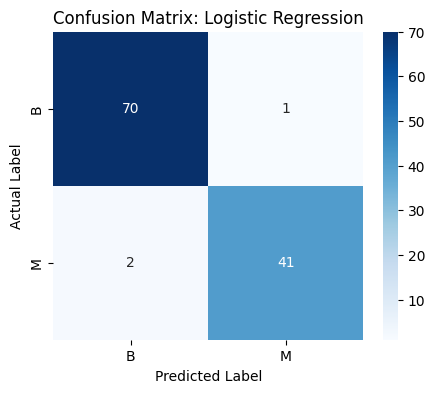



MODEL: Random Forest
Accuracy: 0.9649

Classification Report:
              precision    recall  f1-score   support

           B       0.96      0.99      0.97        71
           M       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



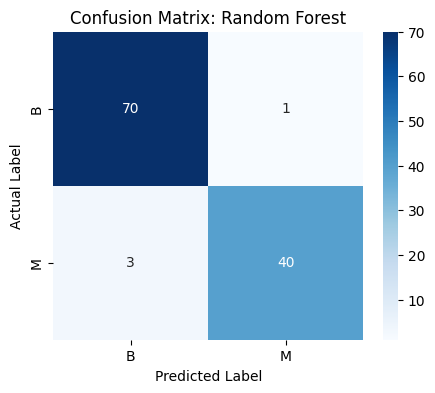



MODEL: SVM (Radial Basis)
Accuracy: 0.9825

Classification Report:
              precision    recall  f1-score   support

           B       0.97      1.00      0.99        71
           M       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



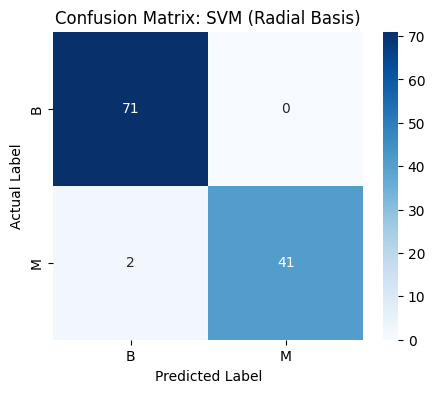

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (Radial Basis)": SVC(kernel='rbf', probability=True)
}

# Train and Evaluate
for name, model in models.items():
    # 1. Fit the model
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)

    # 2. Print Classification Report
    print(f"{'='*30}")
    print(f"MODEL: {name}")
    print(f"{'='*30}")
    print(f"Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, predictions, target_names=le.classes_))

    # 3. Generate and Plot Confusion Matrix
    cm = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()
    print("\n")

## **ROC Curve**

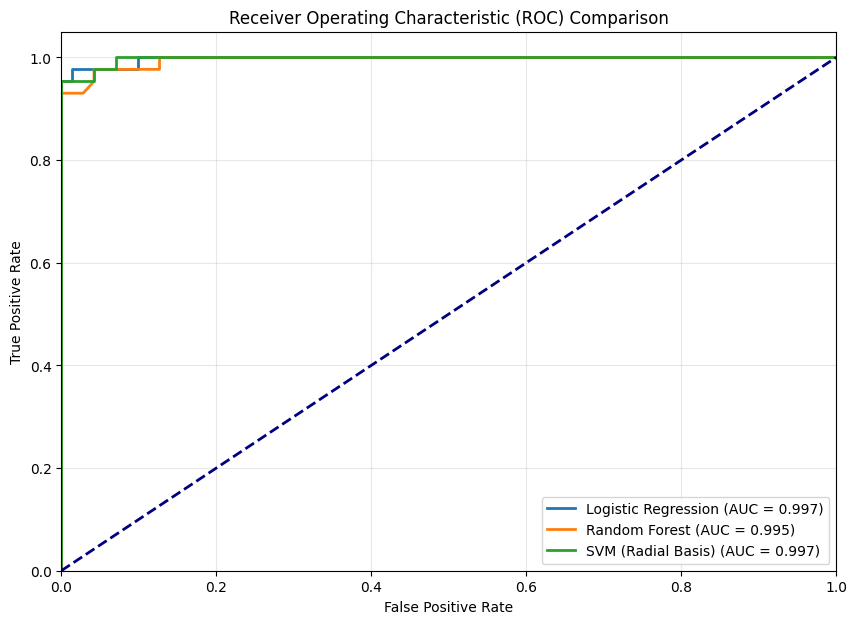

In [11]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 7))

for name, model in models.items():
    # Get probabilities for the positive class (Malignant)
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Comparison')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# **Hyperparameter Optimization using Bayesian Optimization**

In [12]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 14.2 MB/s eta 0:00:00


In [13]:
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):
    # 1. Choose the classifier type
    classifier_name = trial.suggest_categorical("classifier", ["LogisticRegression", "RandomForest", "SVC"])

    # 2. Branch based on the chosen classifier
    if classifier_name == "LogisticRegression":
        c = trial.suggest_float("lr_c", 1e-5, 100, log=True)
        classifier_obj = LogisticRegression(C=c, max_iter=1000)

    elif classifier_name == "RandomForest":
        n_estimators = trial.suggest_int("rf_n_estimators", 50, 300)
        max_depth = trial.suggest_int("rf_max_depth", 2, 32, log=True)
        classifier_obj = RandomForestClassifier(
            n_estimators=n_estimators, max_depth=max_depth, random_state=42
        )

    else: # SVC
        svc_c = trial.suggest_float("svc_c", 1e-5, 100, log=True)
        gamma = trial.suggest_categorical("svc_gamma", ["scale", "auto"])
        classifier_obj = SVC(C=svc_c, gamma=gamma, probability=True)

    # 3. Evaluate using Cross-Validation (on the training set)
    score = cross_val_score(classifier_obj, X_train, y_train, n_jobs=-1, cv=5, scoring='f1').mean()
    return score

# Create and run the study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print(f"Winner Model & Params: {study.best_params}")
print(f"Best CV F1-Score: {study.best_value:.4f}")

[I 2026-05-04 13:26:51,294] A new study created in memory with name: no-name-f2bcbee4-7d6a-4573-8604-8a265241f7ac
[I 2026-05-04 13:26:56,981] Trial 0 finished with value: 0.911062715452531 and parameters: {'classifier': 'RandomForest', 'rf_n_estimators': 93, 'rf_max_depth': 2}. Best is trial 0 with value: 0.911062715452531.
[I 2026-05-04 13:26:57,075] Trial 1 finished with value: 0.8979550978111511 and parameters: {'classifier': 'LogisticRegression', 'lr_c': 0.0026868255508900605}. Best is trial 0 with value: 0.911062715452531.
[I 2026-05-04 13:26:57,271] Trial 2 finished with value: 0.9665140208050655 and parameters: {'classifier': 'SVC', 'svc_c': 5.008393167754354, 'svc_gamma': 'scale'}. Best is trial 2 with value: 0.9665140208050655.
[I 2026-05-04 13:27:04,922] Trial 3 finished with value: 0.9459610198844175 and parameters: {'classifier': 'RandomForest', 'rf_n_estimators': 267, 'rf_max_depth': 14}. Best is trial 2 with value: 0.9665140208050655.
[I 2026-05-04 13:27:08,735] Trial 4 f

Winner Model & Params: {'classifier': 'SVC', 'svc_c': 8.889720797493641, 'svc_gamma': 'auto'}
Best CV F1-Score: 0.9696


In [14]:
# Extract the winner
best_params = study.best_params
model_type = best_params.pop("classifier")

# Re-initialize the winner
if model_type == "LogisticRegression":
    final_model = LogisticRegression(C=best_params["lr_c"], max_iter=1000)
elif model_type == "RandomForest":
    final_model = RandomForestClassifier(
        n_estimators=best_params["rf_n_estimators"],
        max_depth=best_params["rf_max_depth"],
        random_state=42
    )
else:
    final_model = SVC(C=best_params["svc_c"], gamma=best_params["svc_gamma"], probability=True)

# Final Fit and Report
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

print(f"\n--- Final Performance: Optimized {model_type} ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))


--- Final Performance: Optimized SVC ---
              precision    recall  f1-score   support

           B       0.97      0.99      0.98        71
           M       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [15]:
# See which model performed best across all trials
optuna.visualization.plot_slice(study, params=["classifier"]).show()

# See how the F1-score improved over time
optuna.visualization.plot_optimization_history(study).show()

In [16]:
import optuna
from sklearn.model_selection import cross_val_score

# Dictionary to store our best models
best_tuned_models = {}

# --- 1. Optimize Logistic Regression ---
def lr_objective(trial):
    c = trial.suggest_float("C", 1e-5, 100, log=True)
    penalty = trial.suggest_categorical("penalty", ["l2"]) # l1 requires different solver
    model = LogisticRegression(C=c, penalty=penalty, solver='lbfgs', max_iter=1000)
    return cross_val_score(model, X_train, y_train, n_jobs=-1, cv=5, scoring='f1').mean()

# --- 2. Optimize Random Forest ---
def rf_objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 50, 300)
    max_depth = trial.suggest_int("max_depth", 2, 32, log=True)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth,
                                   min_samples_split=min_samples_split, random_state=42)
    return cross_val_score(model, X_train, y_train, n_jobs=-1, cv=5, scoring='f1').mean()

# --- 3. Optimize SVM ---
def svc_objective(trial):
    svc_c = trial.suggest_float("C", 1e-5, 100, log=True)
    gamma = trial.suggest_float("gamma", 1e-5, 10, log=True)
    model = SVC(C=svc_c, gamma=gamma, probability=True)
    return cross_val_score(model, X_train, y_train, n_jobs=-1, cv=5, scoring='f1').mean()

# Running the studies
for name, obj in [("Logistic Regression", lr_objective),
                  ("Random Forest", rf_objective),
                  ("SVM", svc_objective)]:
    print(f"\nOptimizing {name}...")
    study = optuna.create_study(direction="maximize")
    study.optimize(obj, n_trials=30)

    # Store the best parameters
    if name == "Logistic Regression":
        best_tuned_models[name] = LogisticRegression(**study.best_params, max_iter=1000)
    elif name == "Random Forest":
        best_tuned_models[name] = RandomForestClassifier(**study.best_params, random_state=42)
    else:
        best_tuned_models[name] = SVC(**study.best_params, probability=True)

[I 2026-05-04 13:27:44,005] A new study created in memory with name: no-name-0d257b32-3538-45e4-86f9-a5acd5d63ce4
[I 2026-05-04 13:27:44,200] Trial 0 finished with value: 0.011428571428571429 and parameters: {'C': 8.026174190656787e-05, 'penalty': 'l2'}. Best is trial 0 with value: 0.011428571428571429.



Optimizing Logistic Regression...


[I 2026-05-04 13:27:44,423] Trial 1 finished with value: 0.9639008986331199 and parameters: {'C': 1.043310036374444, 'penalty': 'l2'}. Best is trial 1 with value: 0.9639008986331199.
[I 2026-05-04 13:27:44,583] Trial 2 finished with value: 0.9670615658850954 and parameters: {'C': 0.9741919113656555, 'penalty': 'l2'}. Best is trial 2 with value: 0.9670615658850954.
[I 2026-05-04 13:27:44,700] Trial 3 finished with value: 0.9564260656424836 and parameters: {'C': 0.04881985677449502, 'penalty': 'l2'}. Best is trial 2 with value: 0.9670615658850954.
[I 2026-05-04 13:27:44,846] Trial 4 finished with value: 0.011428571428571429 and parameters: {'C': 9.04808244239171e-05, 'penalty': 'l2'}. Best is trial 2 with value: 0.9670615658850954.
[I 2026-05-04 13:27:45,031] Trial 5 finished with value: 0.9579375848032565 and parameters: {'C': 26.49014063689396, 'penalty': 'l2'}. Best is trial 2 with value: 0.9670615658850954.
[I 2026-05-04 13:27:45,164] Trial 6 finished with value: 0.9197930948539093 a


Optimizing Random Forest...


[I 2026-05-04 13:27:51,533] Trial 0 finished with value: 0.9425210084033614 and parameters: {'n_estimators': 142, 'max_depth': 24, 'min_samples_split': 4}. Best is trial 0 with value: 0.9425210084033614.
[I 2026-05-04 13:27:53,918] Trial 1 finished with value: 0.9363671622495152 and parameters: {'n_estimators': 104, 'max_depth': 16, 'min_samples_split': 8}. Best is trial 0 with value: 0.9425210084033614.
[I 2026-05-04 13:27:55,955] Trial 2 finished with value: 0.9081857313255469 and parameters: {'n_estimators': 100, 'max_depth': 2, 'min_samples_split': 5}. Best is trial 0 with value: 0.9425210084033614.
[I 2026-05-04 13:28:00,209] Trial 3 finished with value: 0.9391497962821493 and parameters: {'n_estimators': 120, 'max_depth': 5, 'min_samples_split': 9}. Best is trial 0 with value: 0.9425210084033614.
[I 2026-05-04 13:28:02,538] Trial 4 finished with value: 0.9137764196587727 and parameters: {'n_estimators': 115, 'max_depth': 2, 'min_samples_split': 6}. Best is trial 0 with value: 0.9


Optimizing SVM...


[I 2026-05-04 13:29:05,183] Trial 0 finished with value: 0.0 and parameters: {'C': 0.001453144487007999, 'gamma': 1.490032086626585}. Best is trial 0 with value: 0.0.
[I 2026-05-04 13:29:05,463] Trial 1 finished with value: 0.0 and parameters: {'C': 0.007472509565343767, 'gamma': 0.012012189655534447}. Best is trial 0 with value: 0.0.
[I 2026-05-04 13:29:05,647] Trial 2 finished with value: 0.9614208348941334 and parameters: {'C': 7.206310499083052, 'gamma': 0.0719751202931518}. Best is trial 2 with value: 0.9614208348941334.
[I 2026-05-04 13:29:05,959] Trial 3 finished with value: 0.0 and parameters: {'C': 2.1381039349243994e-05, 'gamma': 0.0006338432868545513}. Best is trial 2 with value: 0.9614208348941334.
[I 2026-05-04 13:29:06,332] Trial 4 finished with value: 0.0 and parameters: {'C': 0.01050601512363813, 'gamma': 0.5606127086969932}. Best is trial 2 with value: 0.9614208348941334.
[I 2026-05-04 13:29:06,753] Trial 5 finished with value: 0.0 and parameters: {'C': 0.0013089357836

In [17]:
from sklearn.metrics import f1_score

results = []

for name, model in best_tuned_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({"Model": name, "Test Accuracy": acc, "Test F1-Score": f1})

    print(f"--- Optimized {name} ---")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

# Final Comparison Table
comparison_df = pd.DataFrame(results)
print("\nFinal Comparison of Tuned Models:")
print(comparison_df.sort_values(by="Test F1-Score", ascending=False))

--- Optimized Logistic Regression ---
              precision    recall  f1-score   support

           B       0.97      0.99      0.98        71
           M       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

--- Optimized Random Forest ---
              precision    recall  f1-score   support

           B       0.96      0.99      0.97        71
           M       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

--- Optimized SVM ---
              precision    recall  f1-score   support

           B       0.97      1.00      0.99        71
           M       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98   

In [18]:
import optuna
import optuna.visualization as vis

# 1. Dictionary to store studies and best models
studies = {}
best_tuned_models = {}

# Define objectives
objectives = {
    "Logistic Regression": lr_objective, # Uses the function from the previous step
    "Random Forest": rf_objective,
    "SVM": svc_objective
}

# 2. Run Optimization Loop
for name, obj in objectives.items():
    print(f"Running Optuna Study for: {name}")
    study = optuna.create_study(direction="maximize")
    study.optimize(obj, n_trials=30)

    # Save the study object for plotting
    studies[name] = study

# 3. Generate Plots for All Models
for name, study in studies.items():
    print(f"\n--- Visualizing Results for {name} ---")

    # Plot 1: Optimization History
    fig_hist = vis.plot_optimization_history(study)
    fig_hist.update_layout(title=f"Optimization History: {name}")
    fig_hist.show()

    # Plot 2: Slice Plot
    fig_slice = vis.plot_slice(study)
    fig_slice.update_layout(title=f"Hyperparameter Slices: {name}")
    fig_slice.show()

[I 2026-05-04 13:29:10,593] A new study created in memory with name: no-name-9a78fc80-f3e6-465e-aeb0-4d0b1cc59c01
[I 2026-05-04 13:29:10,634] Trial 0 finished with value: 0.17674751674751674 and parameters: {'C': 0.00016446813564618596, 'penalty': 'l2'}. Best is trial 0 with value: 0.17674751674751674.
[I 2026-05-04 13:29:10,672] Trial 1 finished with value: 0.0 and parameters: {'C': 5.3301891348010263e-05, 'penalty': 'l2'}. Best is trial 0 with value: 0.17674751674751674.
[I 2026-05-04 13:29:10,724] Trial 2 finished with value: 0.9053928866832093 and parameters: {'C': 0.003745456287557294, 'penalty': 'l2'}. Best is trial 2 with value: 0.9053928866832093.


Running Optuna Study for: Logistic Regression


[I 2026-05-04 13:29:10,783] Trial 3 finished with value: 0.952400055060665 and parameters: {'C': 40.051502467501074, 'penalty': 'l2'}. Best is trial 3 with value: 0.952400055060665.
[I 2026-05-04 13:29:10,843] Trial 4 finished with value: 0.9551281028015005 and parameters: {'C': 35.15766943851026, 'penalty': 'l2'}. Best is trial 4 with value: 0.9551281028015005.
[I 2026-05-04 13:29:10,882] Trial 5 finished with value: 0.8833993985784581 and parameters: {'C': 0.0021624342534050022, 'penalty': 'l2'}. Best is trial 4 with value: 0.9551281028015005.
[I 2026-05-04 13:29:10,944] Trial 6 finished with value: 0.952400055060665 and parameters: {'C': 64.76949870757922, 'penalty': 'l2'}. Best is trial 4 with value: 0.9551281028015005.
[I 2026-05-04 13:29:10,983] Trial 7 finished with value: 0.9197930948539093 and parameters: {'C': 0.0059228128696535145, 'penalty': 'l2'}. Best is trial 4 with value: 0.9551281028015005.
[I 2026-05-04 13:29:11,023] Trial 8 finished with value: 0.0 and parameters: {'

Running Optuna Study for: Random Forest


[I 2026-05-04 13:29:13,862] Trial 0 finished with value: 0.9457844116667646 and parameters: {'n_estimators': 174, 'max_depth': 13, 'min_samples_split': 5}. Best is trial 0 with value: 0.9457844116667646.
[I 2026-05-04 13:29:16,796] Trial 1 finished with value: 0.9327257257667705 and parameters: {'n_estimators': 298, 'max_depth': 4, 'min_samples_split': 6}. Best is trial 0 with value: 0.9457844116667646.
[I 2026-05-04 13:29:20,804] Trial 2 finished with value: 0.9358863930187461 and parameters: {'n_estimators': 268, 'max_depth': 5, 'min_samples_split': 8}. Best is trial 0 with value: 0.9457844116667646.
[I 2026-05-04 13:29:22,743] Trial 3 finished with value: 0.9487651808975338 and parameters: {'n_estimators': 193, 'max_depth': 10, 'min_samples_split': 3}. Best is trial 3 with value: 0.9487651808975338.
[I 2026-05-04 13:29:24,103] Trial 4 finished with value: 0.9327257257667705 and parameters: {'n_estimators': 139, 'max_depth': 28, 'min_samples_split': 8}. Best is trial 3 with value: 0.

Running Optuna Study for: SVM


[I 2026-05-04 13:30:16,476] Trial 0 finished with value: 0.0 and parameters: {'C': 0.006293326097395569, 'gamma': 3.9679284815498628}. Best is trial 0 with value: 0.0.
[I 2026-05-04 13:30:16,718] Trial 1 finished with value: 0.7576744323102915 and parameters: {'C': 24.258341774251623, 'gamma': 0.44184957471714303}. Best is trial 1 with value: 0.7576744323102915.
[I 2026-05-04 13:30:16,907] Trial 2 finished with value: 0.03398692810457517 and parameters: {'C': 1.180466758960876, 'gamma': 4.4365850343232e-05}. Best is trial 1 with value: 0.7576744323102915.
[I 2026-05-04 13:30:16,999] Trial 3 finished with value: 0.9580944204985127 and parameters: {'C': 11.637352967716765, 'gamma': 0.03917329401282358}. Best is trial 3 with value: 0.9580944204985127.
[I 2026-05-04 13:30:17,129] Trial 4 finished with value: 0.9620283025438546 and parameters: {'C': 65.90274760566449, 'gamma': 0.09018418609182786}. Best is trial 4 with value: 0.9620283025438546.
[I 2026-05-04 13:30:17,250] Trial 5 finished 


--- Visualizing Results for Logistic Regression ---



--- Visualizing Results for Random Forest ---



--- Visualizing Results for SVM ---



FINAL OPTIMIZED MODEL: Logistic Regression
              precision    recall  f1-score   support

           B       0.97      0.99      0.98        71
           M       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



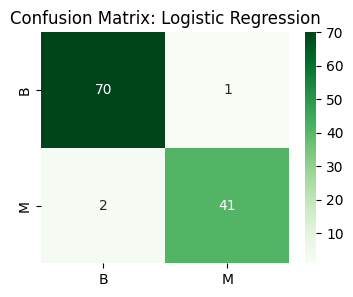


FINAL OPTIMIZED MODEL: Random Forest
              precision    recall  f1-score   support

           B       0.96      0.99      0.97        71
           M       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



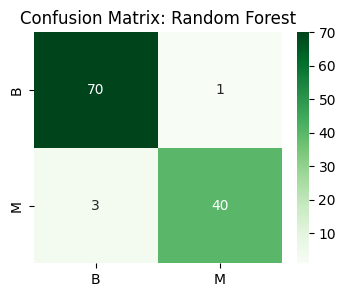


FINAL OPTIMIZED MODEL: SVM
              precision    recall  f1-score   support

           B       0.97      1.00      0.99        71
           M       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



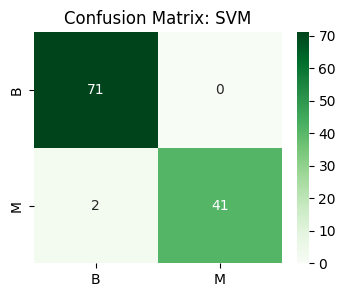

In [19]:
# 1. Initialize models with your specific Optuna winners
optimized_models = {
    "Logistic Regression": LogisticRegression(
        C=1.570946917062941,
        penalty='l2',
        max_iter=1000
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=127,
        max_depth=22,
        min_samples_split=3,
        random_state=42
    ),
    "SVM": SVC(
        C=8.733756058242601,
        gamma=0.0021632548445738205,
        probability=True
    )
}

# 2. Train and generate Final Reports
for name, model in optimized_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{'='*40}")
    print(f"FINAL OPTIMIZED MODEL: {name}")
    print(f"{'='*40}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    # Quick Confusion Matrix for each
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"Confusion Matrix: {name}")
    plt.show()

## **K Fold Cross Validation**

In [20]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("--- Cross-Validation F1-Scores ---")
for name, model in optimized_models.items():
    # Use the full X and y (scaled) for cross-validation
    X_scaled = scaler.fit_transform(X)
    cv_scores = cross_val_score(model, X_scaled, y, cv=skf, scoring='f1')

    print(f"{name}: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

--- Cross-Validation F1-Scores ---
Logistic Regression: 0.9589 (+/- 0.0555)
Random Forest: 0.9405 (+/- 0.0307)
SVM: 0.9605 (+/- 0.0497)


In [21]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd

# 1. Scaling the full dataset for consistent K-Fold results
scaler_final = StandardScaler()
X_scaled = scaler_final.fit_transform(X)

# 2. Setup the K-Fold strategy (5 folds is standard for this dataset size)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Create a dictionary to hold results for comparison
kfold_metrics = []

print("--- Running 5-Fold Cross-Validation (Full Dataset) ---")

for name, model in optimized_models.items():
    # We evaluate both Accuracy and F1-score simultaneously
    cv_results = cross_validate(
        model, X_scaled, y,
        cv=skf,
        scoring=['accuracy', 'f1'],
        n_jobs=-1
    )

    # Store means and standard deviations
    kfold_metrics.append({
        'Model': name,
        'Mean Accuracy': cv_results['test_accuracy'].mean(),
        'Std Accuracy': cv_results['test_accuracy'].std(),
        'Mean F1-Score': cv_results['test_f1'].mean(),
        'Std F1-Score': cv_results['test_f1'].std()
    })

# 4. Display as a summary table
cv_summary_df = pd.DataFrame(kfold_metrics).sort_values(by='Mean F1-Score', ascending=False)
print(cv_summary_df.to_string(index=False))

--- Running 5-Fold Cross-Validation (Full Dataset) ---
              Model  Mean Accuracy  Std Accuracy  Mean F1-Score  Std F1-Score
                SVM       0.971899      0.016990       0.960460      0.024850
Logistic Regression       0.970160      0.019676       0.958863      0.027773
      Random Forest       0.956078      0.011047       0.940536      0.015352


# **Feature Importance & Shap**

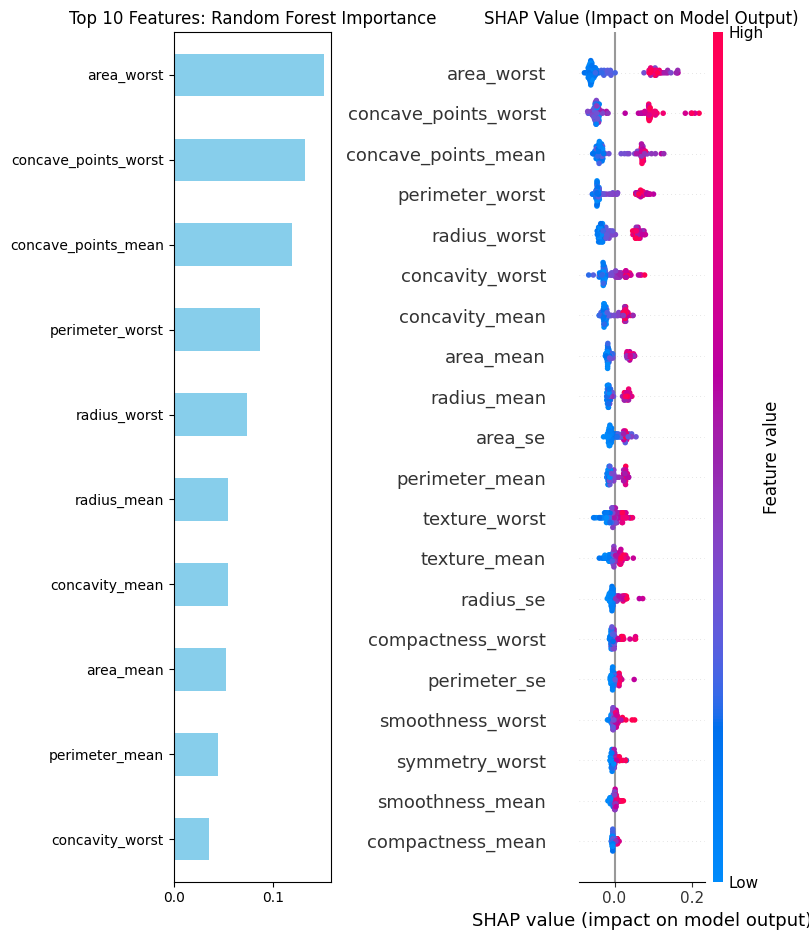

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import shap

# 1. Global Feature Importance (Random Forest)
rf_model = optimized_models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_10_rf = importances.sort_values(ascending=False).head(10)

# 2. SHAP Explanations (Using the SVM or RF model)
# We use a KernelExplainer or TreeExplainer for model-agnostic insights
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# 3. Visualizing Both
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot RF Importance
top_10_rf.plot(kind='barh', ax=ax1, color='skyblue')
ax1.set_title("Top 10 Features: Random Forest Importance")
ax1.invert_yaxis()

# Plot SHAP Summary
plt.sca(ax2)
# Fix: Select SHAP values for the second class (index 1) across all samples and features
shap.summary_plot(shap_values[:, :, 1], X_test, feature_names=X.columns, show=False)
ax2.set_title("SHAP Value (Impact on Model Output)")

plt.tight_layout()
plt.show()

# **How does model complexity (deep learning MLPs vs classical ML classifiers like SVM, Random Forest, Logistic Regression) impact predictive performance, interpretability, and potential clinical deployment in decision-support systems?**

In [23]:
from sklearn.neural_network import MLPClassifier
import time

# 1. Initialize the Deep Learning MLP and existing optimized models
comparison_models = {
    "Logistic Regression": optimized_models["Logistic Regression"],
    "Random Forest": optimized_models["Random Forest"],
    "SVM": optimized_models["SVM"],
    "Deep Learning (MLP)": MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
}

results = []

for name, model in comparison_models.items():
    # Measure Training Time (Deployment factor)
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    # Measure Performance
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    # Store results with qualitative metrics
    results.append({
        "Model": name,
        "F1-Score": round(f1, 4),
        "Accuracy": round(acc, 4),
        "Train Time (s)": round(train_time, 4),
        "Interpretability": "High" if name in ["Logistic Regression", "Random Forest"] else "Low",
        "Clinical Trust": "High (Transparent)" if name != "Deep Learning (MLP)" else "Moderate (Black Box)"
    })

# Display Comparison Table
comparison_df = pd.DataFrame(results)
print(comparison_df.to_string(index=False))

              Model  F1-Score  Accuracy  Train Time (s) Interpretability       Clinical Trust
Logistic Regression    0.9647    0.9737          0.0054             High   High (Transparent)
      Random Forest    0.9524    0.9649          0.4064             High   High (Transparent)
                SVM    0.9762    0.9825          0.0141              Low   High (Transparent)
Deep Learning (MLP)    0.9647    0.9737          0.5925              Low Moderate (Black Box)
